In [1]:
import os
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
import dask
import scipy.stats as st
from matplotlib.colors import BoundaryNorm
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
from matplotlib.figure import Figure
import pandas as pd
import datetime
import copy
import seaborn as sns
from sklearn.neighbors import KernelDensity

In [2]:
def list_dirs(in_dir):
    """
    List sub-directories.
    """
    dirs = []
    for it in os.scandir(in_dir):
        if it.is_dir():
            dirs.append(it.path)
    return dirs

def find_lasso_files(start_dates, root_datadir, in_basename, domain):
    files = []
    # Loop over dates
    for ii in range(0, len(start_dates)):
        # Get sub-directories (separate runs)
        idate = start_dates[ii]
        idirs = list_dirs(f'{root_datadir}/{idate}/')
        if len(idirs) > 0:
            for dd in idirs:
                # Find track stats file
                fname = sorted(glob.glob(f'{dd}/{domain}/stats/{in_basename}*nc'))
                if len(fname) > 0:
                    files.append(fname[0])
    return files

In [3]:
figdir = '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les/figures/'

# CSAPR data directory
dir_obs = '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/csapr/stats4lasso/'
terrain_file = f'/gpfs/wolf/cli120/proj-shared/zfeng/cacti/csapr/corgridded_terrain.c0/topo_cacti_csapr2_large.nc'
radar_lat = -32.1264
radar_lon = -64.7284

basename_obs = 'csapr_trackstats_'
files_obs = sorted(glob.glob(f'{dir_obs}{basename_obs}*nc'))
files_obs

['/gpfs/wolf/cli120/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20181129.0900_20181130.0300.nc',
 '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20181204.0900_20181205.0300.nc',
 '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20181205.0900_20181206.0300.nc',
 '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20181219.0900_20181220.0300.nc',
 '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20190122.0900_20190123.0300.nc',
 '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20190123.0900_20190124.0300.nc',
 '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20190125.0900_20190126.0300.nc',
 '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20190129.0900_20190130.0300.nc',
 '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/csapr/stats4lasso/csapr_trackstats_20190208.0900_20190209.03

In [4]:
# LASSO case dates
start_dates = [
    "20181129", 
    "20181204",
    "20181205", 
    "20181219", 
    "20190122", 
    "20190123",
    "20190125",
    "20190129",
    "20190208",
]

# LASSO tracking directory
rootdir_m = '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les/'
in_basename = 'trackstats_20'

# Domain 4 boundaries
lon_range = [-65.4, -63.1]
lat_range = [-33.3, -30.8]

# Find LASSO files
files_d3 = find_lasso_files(start_dates, rootdir_m, in_basename, 'd3')
files_d4 = find_lasso_files(start_dates, rootdir_m, in_basename, 'd4_15min')
files_d3, files_d4

(['/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les//20181129/gefs03/d3/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les//20181129/gefs00/d3/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les//20181204/gefs19/d3/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les//20181204/gefs18/d3/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les//20181205/gefs01/d3/stats/trackstats_20181205.1200_20181206.0000.nc',
  '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les//20181219/eda09/d3/stats/trackstats_20181219.1200_20181220.0000.nc',
  '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les//20190122/gefs01/d3/stats/trackstats_20190122.1200_20190123.0000.nc',
  '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les//20190123/eda05/d3/stats/trackstats_20190123.1200_20190124.0000.nc',
  '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les//

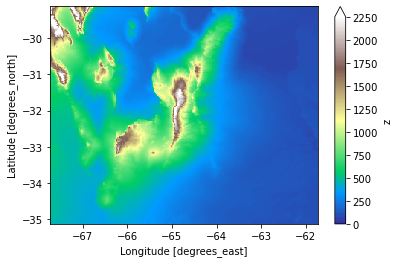

In [5]:
terr = xr.open_dataset(terrain_file)
topoZ = terr['z']
topoLon = terr['x']
topoLat = terr['y']
# topoZ = terr.hgt
# topoLon = terr.longitude
# topoLat = terr.latitude

topoZ.plot(vmin=0, vmax=2250, cmap='terrain')

In [6]:
# Read data (OBS)
ds_o = xr.open_mfdataset(files_obs, concat_dim='tracks', combine='nested').load()
# Renumber tracks to make it continuous
ntracks_o = ds_o.sizes['tracks']
ds_o['tracks'] = np.arange(0, ntracks_o)
print(f'Number of tracks (OBS): {ntracks_o}')

Number of tracks (OBS): 835


In [7]:
# Read data (LASSO D3)
ds_d3 = xr.open_mfdataset(files_d3, concat_dim='tracks', combine='nested').load()
# Renumber tracks to make it continuous
ntracks_d3 = ds_d3.sizes['tracks']
ds_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

Number of tracks (D3): 7843


In [8]:
# Get track min/max lat/lon
minlon_d3 = ds_d3.meanlon.min(dim='times')
maxlon_d3 = ds_d3.meanlon.max(dim='times')
minlat_d3 = ds_d3.meanlat.min(dim='times')
maxlat_d3 = ds_d3.meanlat.max(dim='times')
# Subset D3 tracks that are within D4 boundary
ds_d3 = ds_d3.where((minlon_d3 >= min(lon_range)) & (maxlon_d3 <= max(lon_range)) & \
                    (minlat_d3 >= min(lat_range)) & (maxlat_d3 <= max(lat_range)), drop=True)
# Renumber tracks to make it continuous
ntracks_d3 = ds_d3.sizes['tracks']
ds_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

Number of tracks (D3): 3293


In [9]:
# Read data (LASSO D4)
ds_d4 = xr.open_mfdataset(files_d4, concat_dim='tracks', combine='nested').load()
# Renumber tracks to make it continuous
ntracks_d4 = ds_d4.sizes['tracks']
ds_d4['tracks'] = np.arange(0, ntracks_d4)
print(f'Number of tracks (D4): {ntracks_d4}')

Number of tracks (D4): 3055


In [10]:
time_res_o = ds_o.attrs['time_resolution_hour']
pixel_radius_o = ds_o.attrs['pixel_radius_km']
lifetime_o = ds_o['track_duration'] * time_res_o

start_time_o = ds_o['start_basetime']
end_time_o = ds_o['end_basetime']
end_merge_tracknumber_o = ds_o['end_merge_tracknumber']
start_split_tracknumber_o = ds_o['start_split_tracknumber']
cell_lon_o = ds_o['cell_meanlon']
cell_lat_o = ds_o['cell_meanlat']
cell_area_o = ds_o['cell_area']
maxrange_flag_o = ds_o['maxrange_flag']

maxdbz_o = ds_o['max_dbz']
eth10_o = ds_o['maxETH_10dbz']
eth20_o = ds_o['maxETH_20dbz']
eth30_o = ds_o['maxETH_30dbz']
eth40_o = ds_o['maxETH_40dbz']
eth50_o = ds_o['maxETH_50dbz']

In [11]:
time_res_d3 = ds_d3.attrs['time_resolution_hour']
pixel_radius_d3 = ds_d3.attrs['pixel_radius_km']
lifetime_d3 = ds_d3['track_duration'] * time_res_d3

start_time_d3 = ds_d3['start_basetime']
end_time_d3 = ds_d3['end_basetime']
end_merge_tracknumber_d3 = ds_d3['end_merge_tracknumber']
start_split_tracknumber_d3 = ds_d3['start_split_tracknumber']
cell_lon_d3 = ds_d3['cell_meanlon']
cell_lat_d3 = ds_d3['cell_meanlat']
cell_area_d3 = ds_d3['cell_area']
maxrange_flag_d3 = ds_d3['maxrange_flag']

maxdbz_d3 = ds_d3['max_dbz']
eth10_d3 = ds_d3['maxETH_10dbz']
eth20_d3 = ds_d3['maxETH_20dbz']
eth30_d3 = ds_d3['maxETH_30dbz']
eth40_d3 = ds_d3['maxETH_40dbz']
eth50_d3 = ds_d3['maxETH_50dbz']

In [12]:
time_res_d4 = ds_d4.attrs['time_resolution_hour']
pixel_radius_d4 = ds_d4.attrs['pixel_radius_km']
lifetime_d4 = ds_d4['track_duration'] * time_res_d4

start_time_d4 = ds_d4['start_basetime']
end_time_d4 = ds_d4['end_basetime']
end_merge_tracknumber_d4 = ds_d4['end_merge_tracknumber']
start_split_tracknumber_d4 = ds_d4['start_split_tracknumber']
cell_lon_d4 = ds_d4['cell_meanlon']
cell_lat_d4 = ds_d4['cell_meanlat']
cell_area_d4 = ds_d4['cell_area']
maxrange_flag_d4 = ds_d4['maxrange_flag']

maxdbz_d4 = ds_d4['max_dbz']
eth10_d4 = ds_d4['maxETH_10dbz']
eth20_d4 = ds_d4['maxETH_20dbz']
eth30_d4 = ds_d4['maxETH_30dbz']
eth40_d4 = ds_d4['maxETH_40dbz']
eth50_d4 = ds_d4['maxETH_50dbz']

In [13]:
# Find tracks not end with merge or not start with split
nonmerge_o = np.where(np.isnan(end_merge_tracknumber_o))[0]
nonsplit_o = np.where(np.isnan(start_split_tracknumber_o))[0]
ntracks_nonmerge_o = len(nonmerge_o)
ntracks_nonsplit_o = len(nonsplit_o)
print(f'Number of non-merge tracks (OBS): {ntracks_nonmerge_o}')
print(f'Number of non-split tracks (OBS): {ntracks_nonsplit_o}')

merge_o = np.where(end_merge_tracknumber_o > 0)[0]
split_o = np.where(start_split_tracknumber_o > 0)[0]
ntracks_merge_o = len(merge_o)
ntracks_split_o = len(split_o)
print(f'Number of merge tracks (OBS): {ntracks_merge_o}')
print(f'Number of split tracks (OBS): {ntracks_split_o}')

Number of non-merge tracks (OBS): 577
Number of non-split tracks (OBS): 578
Number of merge tracks (OBS): 258
Number of split tracks (OBS): 257


In [14]:
# Find tracks not end with merge or not start with split
nonmerge_d3 = np.where(np.isnan(end_merge_tracknumber_d3))[0]
nonsplit_d3 = np.where(np.isnan(start_split_tracknumber_d3))[0]
ntracks_nonmerge_d3 = len(nonmerge_d3)
ntracks_nonsplit_d3 = len(nonsplit_d3)
print(f'Number of non-merge tracks (D3): {ntracks_nonmerge_d3}')
print(f'Number of non-split tracks (D3): {ntracks_nonsplit_d3}')

merge_d3 = np.where(end_merge_tracknumber_d3 > 0)[0]
split_d3 = np.where(start_split_tracknumber_d3 > 0)[0]
ntracks_merge_d3 = len(merge_d3)
ntracks_split_d3 = len(split_d3)
print(f'Number of merge tracks (D3): {ntracks_merge_d3}')
print(f'Number of split tracks (D3): {ntracks_split_d3}')

Number of non-merge tracks (D3): 1918
Number of non-split tracks (D3): 1891
Number of merge tracks (D3): 1375
Number of split tracks (D3): 1402


In [15]:
# Find tracks not end with merge or not start with split
nonmerge_d4 = np.where(np.isnan(end_merge_tracknumber_d4))[0]
nonsplit_d4 = np.where(np.isnan(start_split_tracknumber_d4))[0]
ntracks_nonmerge_d4 = len(nonmerge_d4)
ntracks_nonsplit_d4 = len(nonsplit_d4)
print(f'Number of non-merge tracks (D4): {ntracks_nonmerge_d4}')
print(f'Number of non-split tracks (D4): {ntracks_nonsplit_d4}')

merge_d4 = np.where(end_merge_tracknumber_d4 > 0)[0]
split_d4 = np.where(start_split_tracknumber_d4 > 0)[0]
ntracks_merge_d4 = len(merge_d4)
ntracks_split_d4 = len(split_d4)
print(f'Number of merge tracks (D4): {ntracks_merge_d4}')
print(f'Number of split tracks (D4): {ntracks_split_d4}')

Number of non-merge tracks (D4): 1830
Number of non-split tracks (D4): 1884
Number of merge tracks (D4): 1225
Number of split tracks (D4): 1171


In [16]:
start_lon_o = cell_lon_o.isel(times=0)
start_lat_o = cell_lat_o.isel(times=0)
start_lon_nonsplit_o = cell_lon_o.isel(tracks=nonsplit_o, times=0)
start_lat_nonsplit_o = cell_lat_o.isel(tracks=nonsplit_o, times=0)

In [17]:
start_lon_d3 = cell_lon_d3.isel(times=0)
start_lat_d3 = cell_lat_d3.isel(times=0)
start_lon_nonsplit_d3 = cell_lon_d3.isel(tracks=nonsplit_d3, times=0)
start_lat_nonsplit_d3 = cell_lat_d3.isel(tracks=nonsplit_d3, times=0)

In [18]:
start_lon_d4 = cell_lon_d4.isel(times=0)
start_lat_d4 = cell_lat_d4.isel(times=0)
start_lon_nonsplit_d4 = cell_lon_d4.isel(tracks=nonsplit_d4, times=0)
start_lat_nonsplit_d4 = cell_lat_d4.isel(tracks=nonsplit_d4, times=0)

In [19]:
# buffer = 0.05
# minlon, maxlon = np.nanmin([start_lon_d4.values, end_lon])-buffer, np.nanmax([start_lon_d4.values, end_lon])+buffer
# minlat, maxlat = np.nanmin([start_lat_d4.values, end_lat])-buffer, np.nanmax([start_lat_d4.values, end_lat])+buffer
# print(minlon, maxlon, minlat, maxlat)

In [20]:
# Set domain boundary based on overlap area between OBS and D4
minlon, maxlon = -65.4, -63.5
minlat, maxlat = -33.1, -31.1
buffer = 0.05
bins = [24, 24]
ranges = [[minlon+buffer,maxlon-buffer], [minlat+buffer,maxlat-buffer]]

In [21]:
hist2d_startloc_o, xbins, ybins = np.histogram2d(start_lon_o.values, start_lat_o.values, bins=bins, range=ranges)
hist2d_startloc_nonsplit_o, xbins, ybins = np.histogram2d(start_lon_nonsplit_o.values, start_lat_nonsplit_o.values, bins=bins, range=ranges)
hist2d_startloc_o = hist2d_startloc_o.transpose()
hist2d_startloc_nonsplit_o = hist2d_startloc_nonsplit_o.transpose()

In [22]:
hist2d_startloc_d3, xbins, ybins = np.histogram2d(start_lon_d3.values, start_lat_d3.values, bins=bins, range=ranges)
hist2d_startloc_nonsplit_d3, xbins, ybins = np.histogram2d(start_lon_nonsplit_d3.values, start_lat_nonsplit_d3.values, bins=bins, range=ranges)
hist2d_startloc_d3 = hist2d_startloc_d3.transpose()
hist2d_startloc_nonsplit_d3 = hist2d_startloc_nonsplit_d3.transpose()

In [23]:
hist2d_startloc_d4, xbins, ybins = np.histogram2d(start_lon_d4.values, start_lat_d4.values, bins=bins, range=ranges)
hist2d_startloc_nonsplit_d4, xbins, ybins = np.histogram2d(start_lon_nonsplit_d4.values, start_lat_nonsplit_d4.values, bins=bins, range=ranges)
hist2d_startloc_d4 = hist2d_startloc_d4.transpose()
hist2d_startloc_nonsplit_d4 = hist2d_startloc_nonsplit_d4.transpose()

In [24]:
np.diff(xbins), np.diff(ybins)

(array([0.075, 0.075, 0.075, 0.075, 0.075, 0.075, 0.075, 0.075, 0.075,
        0.075, 0.075, 0.075, 0.075, 0.075, 0.075, 0.075, 0.075, 0.075,
        0.075, 0.075, 0.075, 0.075, 0.075, 0.075]),
 array([0.07916667, 0.07916667, 0.07916667, 0.07916667, 0.07916667,
        0.07916667, 0.07916667, 0.07916667, 0.07916667, 0.07916667,
        0.07916667, 0.07916667, 0.07916667, 0.07916667, 0.07916667,
        0.07916667, 0.07916667, 0.07916667, 0.07916667, 0.07916667,
        0.07916667, 0.07916667, 0.07916667, 0.07916667]))

In [25]:
xmin = minlon+buffer
xmax = maxlon-buffer
ymin = minlat+buffer
ymax = maxlat-buffer
# dx = 0.075
# dy = 0.075
dx = 0.04
dy = 0.04
xx, yy = np.mgrid[xmin:xmax:dx, ymin:ymax:dy]
grids = np.vstack([xx.ravel(), yy.ravel()])

In [26]:
# Calculate KDE of CI location 
values_o = np.vstack([start_lon_o.data.ravel(), start_lat_o.data.ravel()])
kernel_o = st.gaussian_kde(values_o)
kde_startloc_o = np.reshape(kernel_o(grids).T, xx.shape)

# Non-split CI
values_nonsplit_o = np.vstack([start_lon_nonsplit_o.data.ravel(), start_lat_nonsplit_o.data.ravel()])
kernel_nonsplit_o = st.gaussian_kde(values_nonsplit_o)
kde_startloc_nonsplit_o = np.reshape(kernel_nonsplit_o(grids).T, xx.shape)

In [27]:
# Calculate KDE of CI location 
values_d3 = np.vstack([start_lon_d3.data.ravel(), start_lat_d3.data.ravel()])
kernel_d3 = st.gaussian_kde(values_d3)
kde_startloc_d3 = np.reshape(kernel_d3(grids).T, xx.shape)

# Non-split CI
values_nonsplit_d3 = np.vstack([start_lon_nonsplit_d3.data.ravel(), start_lat_nonsplit_d3.data.ravel()])
kernel_nonsplit_d3 = st.gaussian_kde(values_nonsplit_d3)
kde_startloc_nonsplit_d3 = np.reshape(kernel_nonsplit_d3(grids).T, xx.shape)

In [28]:
# Calculate KDE of CI location 
values_d4 = np.vstack([start_lon_d4.data.ravel(), start_lat_d4.data.ravel()])
kernel_d4 = st.gaussian_kde(values_d4)
kde_startloc_d4 = np.reshape(kernel_d4(grids).T, xx.shape)

# Non-split CI
values_nonsplit_d4 = np.vstack([start_lon_nonsplit_d4.data.ravel(), start_lat_nonsplit_d4.data.ravel()])
kernel_nonsplit_d4 = st.gaussian_kde(values_nonsplit_d4)
kde_startloc_nonsplit_d4 = np.reshape(kernel_nonsplit_d4(grids).T, xx.shape)

In [29]:
kde_startloc_d4.shape

(46, 48)

<a list of 9 text.Text objects>

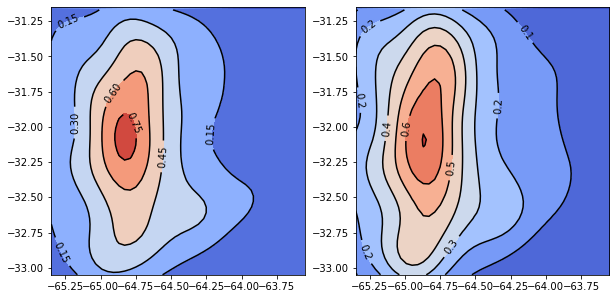

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
ax = axes[0]
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
cfset = ax.contourf(xx, yy, kde_startloc_o, cmap='coolwarm')
ax.imshow(np.rot90(kde_startloc_o), cmap='coolwarm', extent=[xmin, xmax, ymin, ymax])
cset = ax.contour(xx, yy, kde_startloc_o, colors='k')
ax.clabel(cset, inline=1, fontsize=10)

ax = axes[1]
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
cfset = ax.contourf(xx, yy, kde_startloc_nonsplit_o, cmap='coolwarm')
ax.imshow(np.rot90(kde_startloc_nonsplit_o), cmap='coolwarm', extent=[xmin, xmax, ymin, ymax])
cset = ax.contour(xx, yy, kde_startloc_nonsplit_o, colors='k')
ax.clabel(cset, inline=1, fontsize=10)

In [31]:
# fig = plt.figure(figsize=(8,8))
# ax = fig.gca()
# ax.set_xlim(xmin, xmax)
# ax.set_ylim(ymin, ymax)
# cfset = ax.contourf(xx, yy, kde_startloc_d3, cmap='coolwarm')
# ax.imshow(np.rot90(kde_startloc_d3), cmap='coolwarm', extent=[xmin, xmax, ymin, ymax])
# cset = ax.contour(xx, yy, kde_startloc_d3, colors='k')
# ax.clabel(cset, inline=1, fontsize=10)

In [32]:
# fig = plt.figure(figsize=(8,8))
# ax = fig.gca()
# ax.set_xlim(xmin, xmax)
# ax.set_ylim(ymin, ymax)
# cfset = ax.contourf(xx, yy, kde_startloc_d4, cmap='coolwarm')
# ax.imshow(np.rot90(kde_startloc_d4), cmap='coolwarm', extent=[xmin, xmax, ymin, ymax])
# cset = ax.contour(xx, yy, kde_startloc_d4, colors='k')
# ax.clabel(cset, inline=1, fontsize=10)

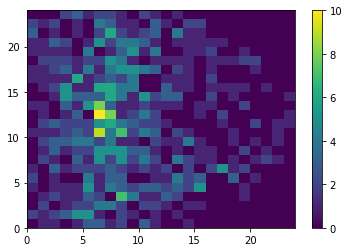

In [33]:
plt.pcolormesh(hist2d_startloc_o)
plt.colorbar()

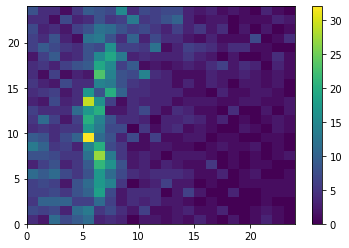

In [34]:
plt.pcolormesh(hist2d_startloc_d3)
plt.colorbar()

In [35]:
# plt.pcolormesh(hist2d_startloc_d4)
# plt.colorbar()

In [36]:
def plot_3heatmaps(dataarr, lonarr, latarr, topoZ, topoLon, topoLat, levels, cmaps, cmap_topo, cblabels, titles, figname, eSDC=None):
    mpl.rcParams['font.size'] = 12
    mpl.rcParams['font.family'] = 'Helvetica'
    fig, axes = plt.subplots(1, 3, figsize=(15.5,5), dpi=100)
    marker_style = dict(color='k', linestyle='none', marker='o', markersize=12, markerfacecolor='red')
    topo_levs = [500,1000,1500,2000,2500]

    ax1 = axes[0]
    Zm = np.ma.masked_where(dataarr[0] == 0, dataarr[0])
    cmap = plt.get_cmap(cmaps[0])
    norm = mpl.colors.BoundaryNorm(boundaries=levels[0], ncolors=cmap.N)
    p1 = ax1.pcolormesh(lonarr, latarr, Zm, norm=norm, cmap=cmap)
    cb = plt.colorbar(p1, ax=ax1, label=cblabels[0])
    ax1.set_xlabel('Longitude')
    ax1.set_ylabel('Latitude')
    ax1.set_title(titles[0], loc='left')
    ax1.set_xlim(np.min(lonarr), np.max(lonarr))
    ax1.set_ylim(np.min(latarr), np.max(latarr))
    ax1.set_xticks(np.arange(-65., maxlon, 0.5))
    ax1.set_yticks(np.arange(-33, maxlat, 0.5))
    ax1.contour(topoLon, topoLat, topoZ, levels=topo_levs, cmap=cmap_topo, linewidths=1.5)
    ax1.plot(radar_lon, radar_lat, **marker_style)
    ax1.grid(ls='--')
    if eSDC is not None:
        ax1.axvline(x=eSDC, color='magenta', lw=2)
    # Legend for terrain
    custom_lines = [mpl.lines.Line2D([0], [0], color=plt.get_cmap(cmap_topo)(0.8), lw=2)]
    ax1.legend(custom_lines, ['Terrain'], loc='upper right')

    ax2 = axes[1]
    Zm = np.ma.masked_where(dataarr[1] == 0, dataarr[1])
    cmap = plt.get_cmap(cmaps[1])
    norm = mpl.colors.BoundaryNorm(boundaries=levels[1], ncolors=cmap.N)
    p2 = ax2.pcolormesh(lonarr, latarr, Zm, norm=norm, cmap=cmap)
    cb = plt.colorbar(p2, ax=ax2, label=cblabels[1])
    ax2.set_xlabel('Longitude')
#     ax2.set_ylabel('Latitude')
    ax2.set_title(titles[1], loc='left')
    ax2.set_xlim(np.min(lonarr), np.max(lonarr))
    ax2.set_ylim(np.min(latarr), np.max(latarr))
    ax2.set_xticks(np.arange(-65., maxlon, 0.5))
    ax2.set_yticks(np.arange(-33, maxlat, 0.5))
    ax2.contour(topoLon, topoLat, topoZ, levels=topo_levs, cmap=cmap_topo, linewidths=1.5)
    ax2.plot(radar_lon, radar_lat, **marker_style)
    ax2.grid(ls='--')
    if eSDC is not None:
        ax2.axvline(x=eSDC, color='magenta', lw=2)
    ax2.legend(custom_lines, ['Terrain'], loc='upper right')

    ax3 = axes[2]
    Zm = np.ma.masked_where(dataarr[2] == 0, dataarr[2])
    cmap = plt.get_cmap(cmaps[2])
    norm = mpl.colors.BoundaryNorm(boundaries=levels[2], ncolors=cmap.N)
    p3 = ax3.pcolormesh(lonarr, latarr, Zm, norm=norm, cmap=cmap)
    cb = plt.colorbar(p3, ax=ax3, label=cblabels[1])
    ax3.set_xlabel('Longitude')
#     ax3.set_ylabel('Latitude')
    ax3.set_title(titles[2], loc='left')
    ax3.set_xlim(np.min(lonarr), np.max(lonarr))
    ax3.set_ylim(np.min(latarr), np.max(latarr))
    ax3.set_xticks(np.arange(-65., maxlon, 0.5))
    ax3.set_yticks(np.arange(-33, maxlat, 0.5))
    ax3.contour(topoLon, topoLat, topoZ, levels=topo_levs, cmap=cmap_topo, linewidths=1.5)
    ax3.plot(radar_lon, radar_lat, **marker_style)
    ax3.grid(ls='--')
    if eSDC is not None:
        ax3.axvline(x=eSDC, color='magenta', lw=2)
    ax3.legend(custom_lines, ['Terrain'], loc='upper right')

    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', facecolor='w', dpi=300)
    
    return fig

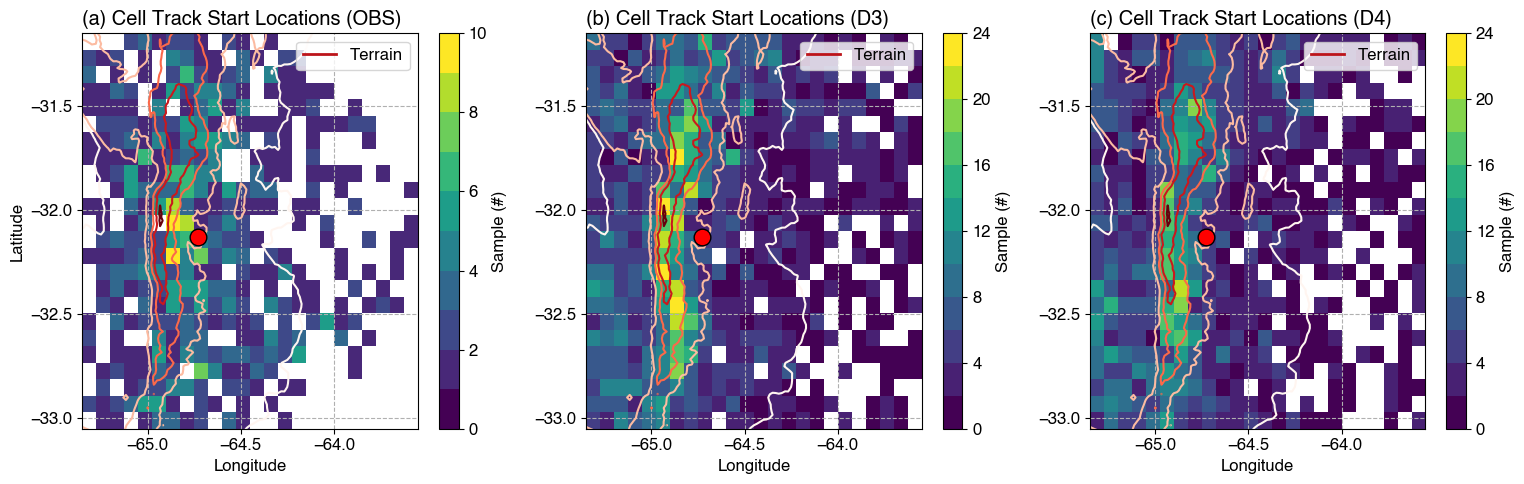

In [37]:
dataarr = [hist2d_startloc_o, hist2d_startloc_d3, hist2d_startloc_d4]
levels = [np.arange(0, 11, 1), np.arange(0, 24.1, 2), np.arange(0, 24.1, 2)]
cmap = ['viridis', 'viridis', 'viridis']
cmap_topo = 'Reds'
titles = ['(a) Cell Track Start Locations (OBS)', '(b) Cell Track Start Locations (D3)', '(c) Cell Track Start Locations (D4)']
cblabels = ['Sample (#)', 'Sample (#)', 'Sample (#)']
figname = f'{figdir}celltrack_startend_loc_0.1.png'
fig = plot_3heatmaps(dataarr, xbins, ybins, topoZ, topoLon, topoLat, levels, cmap, cmap_topo, cblabels, titles, figname)

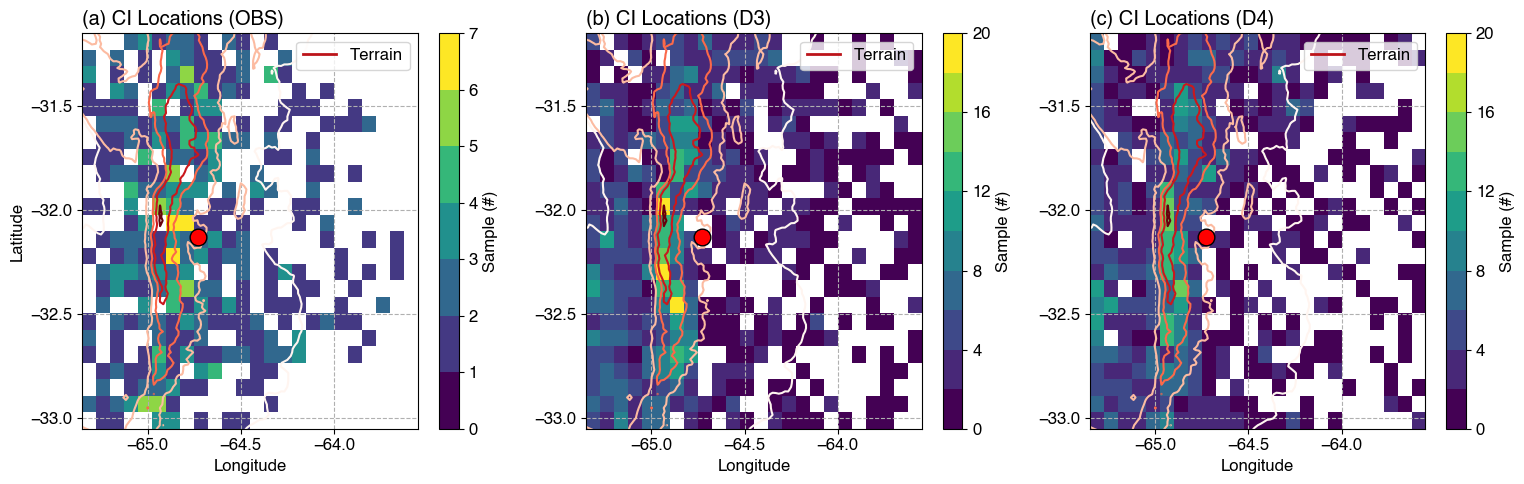

In [38]:
dataarr = [hist2d_startloc_nonsplit_o, hist2d_startloc_nonsplit_d3, hist2d_startloc_nonsplit_d4]
levels = [np.arange(0, 7.1, 1), np.arange(0, 20.1, 2), np.arange(0, 20.1, 2)]
cmap = ['viridis', 'viridis', 'viridis']
cmap_topo = 'Reds'
titles = ['(a) CI Locations (OBS)', '(b) CI Locations (D3)', '(c) CI Locations (D4)']
cblabels = ['Sample (#)', 'Sample (#)', 'Sample (#)']
figname = f'{figdir}celltrack_startend_loc_nonsplit_0.1.png'
fig = plot_3heatmaps(dataarr, xbins, ybins, topoZ, topoLon, topoLat, levels, cmap, cmap_topo, cblabels, titles, figname)

In [39]:
def plot_3heatmaps_kde(dataarr, lonarr, latarr, topoZ, topoLon, topoLat, levels, cmaps, cmap_topo, cblabels, titles, figname, eSDC=None):
    mpl.rcParams['font.size'] = 12
    mpl.rcParams['font.family'] = 'Helvetica'
    fig, axes = plt.subplots(1, 3, figsize=(15.5,5), dpi=100)
    marker_style = dict(color='k', linestyle='none', marker='o', markersize=12, markerfacecolor='red')
    topo_levs = [500,1000,1500,2000,2500]

    ax1 = axes[0]
    Zm = dataarr[0]
    cmap = plt.get_cmap(cmaps[0])
    norm = mpl.colors.BoundaryNorm(boundaries=levels[0], ncolors=cmap.N)
    # p1 = ax1.pcolormesh(lonarr, latarr, Zm, norm=norm, cmap=cmap)
    p1 = ax1.contourf(lonarr, latarr, Zm, cmap=cmap, levels=levels[0], extend='both')
    cb = plt.colorbar(p1, ax=ax1, label=cblabels[0])
    ax1.set_xlabel('Longitude')
    ax1.set_ylabel('Latitude')
    ax1.set_title(titles[0], loc='left')
    ax1.set_xlim(np.min(lonarr), np.max(lonarr))
    ax1.set_ylim(np.min(latarr), np.max(latarr))
    ax1.set_xticks(np.arange(-65., maxlon, 0.5))
    ax1.set_yticks(np.arange(-33, maxlat, 0.5))
    ax1.contour(topoLon, topoLat, topoZ, levels=topo_levs, cmap=cmap_topo, linewidths=1.5)
    ax1.plot(radar_lon, radar_lat, **marker_style)
    ax1.grid(ls='--')
    if eSDC is not None:
        ax1.axvline(x=eSDC, color='magenta', lw=2)
    # Legend for terrain
    custom_lines = [mpl.lines.Line2D([0], [0], color=plt.get_cmap(cmap_topo)(0.8), lw=2)]
    ax1.legend(custom_lines, ['Terrain'], loc='upper right')

    ax2 = axes[1]
    Zm = dataarr[1]
    cmap = plt.get_cmap(cmaps[1])
    norm = mpl.colors.BoundaryNorm(boundaries=levels[1], ncolors=cmap.N)
    p2 = ax2.contourf(lonarr, latarr, Zm, cmap=cmap, levels=levels[1], extend='both')
    cb = plt.colorbar(p2, ax=ax2, label=cblabels[1])
    ax2.set_xlabel('Longitude')
#     ax2.set_ylabel('Latitude')
    ax2.set_title(titles[1], loc='left')
    ax2.set_xlim(np.min(lonarr), np.max(lonarr))
    ax2.set_ylim(np.min(latarr), np.max(latarr))
    ax2.set_xticks(np.arange(-65., maxlon, 0.5))
    ax2.set_yticks(np.arange(-33, maxlat, 0.5))
    ax2.contour(topoLon, topoLat, topoZ, levels=topo_levs, cmap=cmap_topo, linewidths=1.5)
    ax2.plot(radar_lon, radar_lat, **marker_style)
    ax2.grid(ls='--')
    if eSDC is not None:
        ax2.axvline(x=eSDC, color='magenta', lw=2)
    ax2.legend(custom_lines, ['Terrain'], loc='upper right')

    ax3 = axes[2]
    Zm = dataarr[2]
    cmap = plt.get_cmap(cmaps[2])
    norm = mpl.colors.BoundaryNorm(boundaries=levels[2], ncolors=cmap.N)
    p3 = ax3.contourf(lonarr, latarr, Zm, cmap=cmap, levels=levels[2], extend='both')
    cb = plt.colorbar(p3, ax=ax3, label=cblabels[1])
    ax3.set_xlabel('Longitude')
#     ax3.set_ylabel('Latitude')
    ax3.set_title(titles[2], loc='left')
    ax3.set_xlim(np.min(lonarr), np.max(lonarr))
    ax3.set_ylim(np.min(latarr), np.max(latarr))
    ax3.set_xticks(np.arange(-65., maxlon, 0.5))
    ax3.set_yticks(np.arange(-33, maxlat, 0.5))
    ax3.contour(topoLon, topoLat, topoZ, levels=topo_levs, cmap=cmap_topo, linewidths=1.5)
    ax3.plot(radar_lon, radar_lat, **marker_style)
    ax3.grid(ls='--')
    if eSDC is not None:
        ax3.axvline(x=eSDC, color='magenta', lw=2)
    ax3.legend(custom_lines, ['Terrain'], loc='upper right')

    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', facecolor='w', dpi=300)
    
    return fig

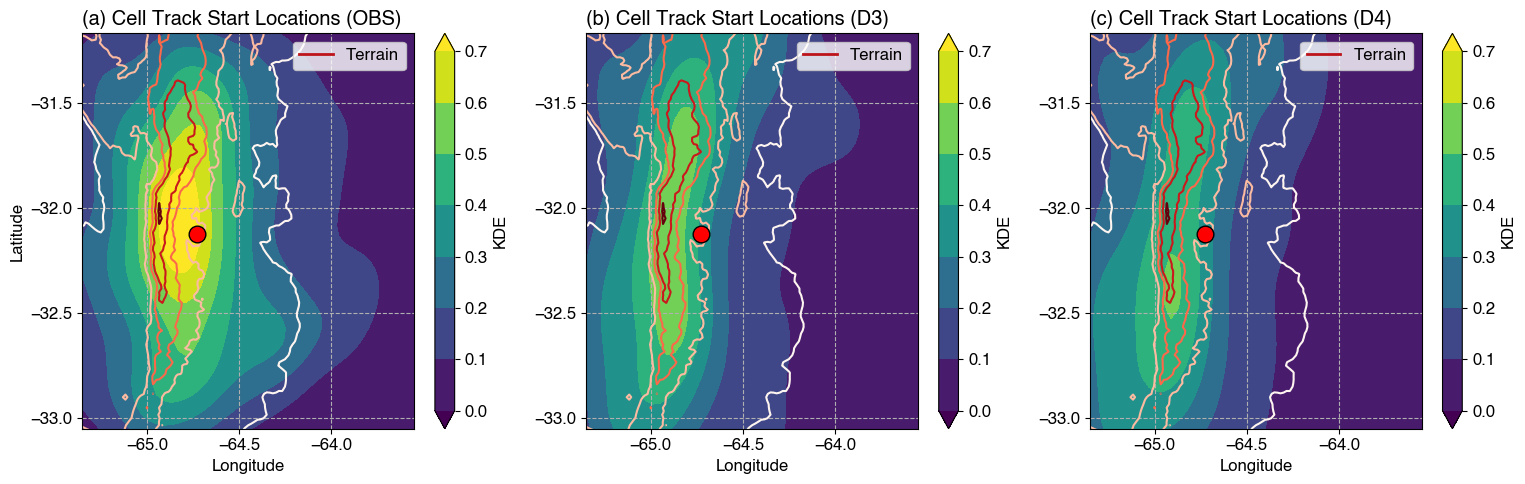

In [40]:
dataarr = [kde_startloc_o, kde_startloc_d3, kde_startloc_d4]
lev = np.arange(0, 0.71, 0.1)
levels = [lev, lev, lev]
cmap = ['viridis', 'viridis', 'viridis']
cmap_topo = 'Reds'
titles = ['(a) Cell Track Start Locations (OBS)', '(b) Cell Track Start Locations (D3)', '(c) Cell Track Start Locations (D4)']
cblabels = ['KDE', 'KDE', 'KDE']
figname = f'{figdir}celltrack_startend_loc_kde.png'
fig = plot_3heatmaps_kde(dataarr, xx, yy, topoZ, topoLon, topoLat, levels, cmap, cmap_topo, cblabels, titles, figname)

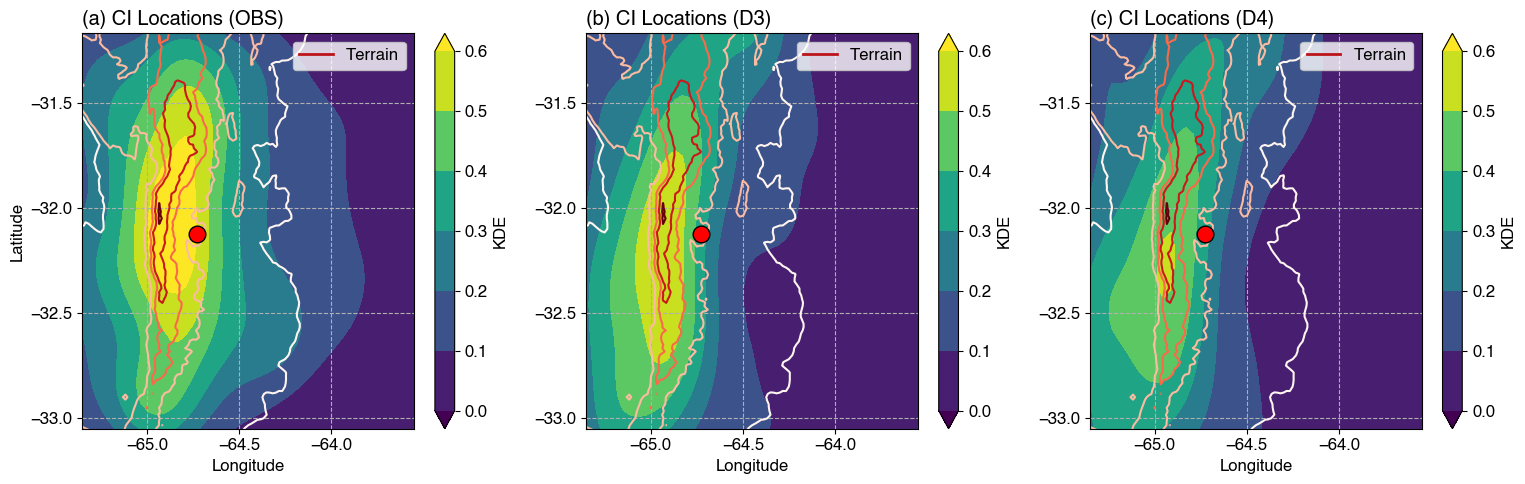

In [41]:
dataarr = [kde_startloc_nonsplit_o, kde_startloc_nonsplit_d3, kde_startloc_nonsplit_d4]
lev = np.arange(0, 0.61, 0.1)
levels = [lev, lev, lev]
cmap = ['viridis', 'viridis', 'viridis']
cmap_topo = 'Reds'
titles = ['(a) CI Locations (OBS)', '(b) CI Locations (D3)', '(c) CI Locations (D4)']
cblabels = ['KDE', 'KDE', 'KDE']
figname = f'{figdir}celltrack_startend_loc_nonsplit_kde.png'
fig = plot_3heatmaps_kde(dataarr, xx, yy, topoZ, topoLon, topoLat, levels, cmap, cmap_topo, cblabels, titles, figname)

In [42]:
bins_lifetime = np.arange(21)*0.25
bins_lifetime_c = bins_lifetime[:-1] + np.diff(bins_lifetime)/2
hist_lifetime_o, bins = np.histogram(lifetime_o, bins=bins_lifetime, range=(0,5), density=True)
hist_lifetime_nonmerge_o, bins = np.histogram(lifetime_o.isel(tracks=nonmerge_o), bins=bins_lifetime, range=(0,5), density=True)

hist_lifetime_d3, bins = np.histogram(lifetime_d3, bins=bins_lifetime, range=(0,5), density=True)
hist_lifetime_nonmerge_d3, bins = np.histogram(lifetime_d3.isel(tracks=nonmerge_d3), bins=bins_lifetime, range=(0,5), density=True)

hist_lifetime_d4, bins = np.histogram(lifetime_d4, bins=bins_lifetime, range=(0,5), density=True)
hist_lifetime_nonmerge_d4, bins = np.histogram(lifetime_d4.isel(tracks=nonmerge_d4), bins=bins_lifetime, range=(0,5), density=True)

In [43]:
bin_cellarea = np.arange(1, 3.01, 0.1)
bin_maxdbz = np.arange(10, 70.1, 2.5)
bin_ctt = np.arange(-100,10.1,5)
bin_eth = np.arange(0,20.1,1)

hist2d_cellarea_maxdbz_o, xbin, ybin = np.histogram2d(np.log10(cell_area_o).max(dim='times'), maxdbz_o.max(dim='times'), bins=[bin_cellarea, bin_maxdbz])
hist2d_eth20_maxdbz_o, xbin, ybin = np.histogram2d(eth20_o.max(dim='times'), maxdbz_o.max(dim='times'), bins=[bin_eth, bin_maxdbz])
hist2d_cellarea_eth20_o, xbin, ybin = np.histogram2d(np.log10(cell_area_o).max(dim='times'), eth20_o.max(dim='times'), bins=[bin_cellarea, bin_eth])

In [44]:
hist2d_cellarea_maxdbz_d3, xbin, ybin = np.histogram2d(np.log10(cell_area_d3).max(dim='times'), maxdbz_d3.max(dim='times'), bins=[bin_cellarea, bin_maxdbz])
hist2d_eth20_maxdbz_d3, xbin, ybin = np.histogram2d(eth20_d3.max(dim='times'), maxdbz_d3.max(dim='times'), bins=[bin_eth, bin_maxdbz])
hist2d_cellarea_eth20_d3, xbin, ybin = np.histogram2d(np.log10(cell_area_d3).max(dim='times'), eth20_d3.max(dim='times'), bins=[bin_cellarea, bin_eth])

In [45]:
hist2d_cellarea_maxdbz_d4, xbin, ybin = np.histogram2d(np.log10(cell_area_d4).max(dim='times'), maxdbz_d4.max(dim='times'), bins=[bin_cellarea, bin_maxdbz])
hist2d_eth20_maxdbz_d4, xbin, ybin = np.histogram2d(eth20_d4.max(dim='times'), maxdbz_d4.max(dim='times'), bins=[bin_eth, bin_maxdbz])
hist2d_cellarea_eth20_d4, xbin, ybin = np.histogram2d(np.log10(cell_area_d4).max(dim='times'), eth20_d4.max(dim='times'), bins=[bin_cellarea, bin_eth])

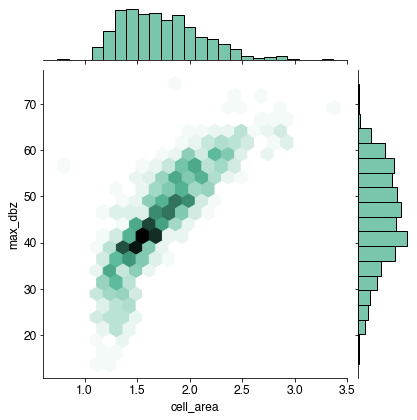

In [46]:
sns.jointplot(x=np.log10(cell_area_o).max(dim='times'), y=maxdbz_o.max(dim='times'), kind="hex", color="#4CB391")

In [47]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """ Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

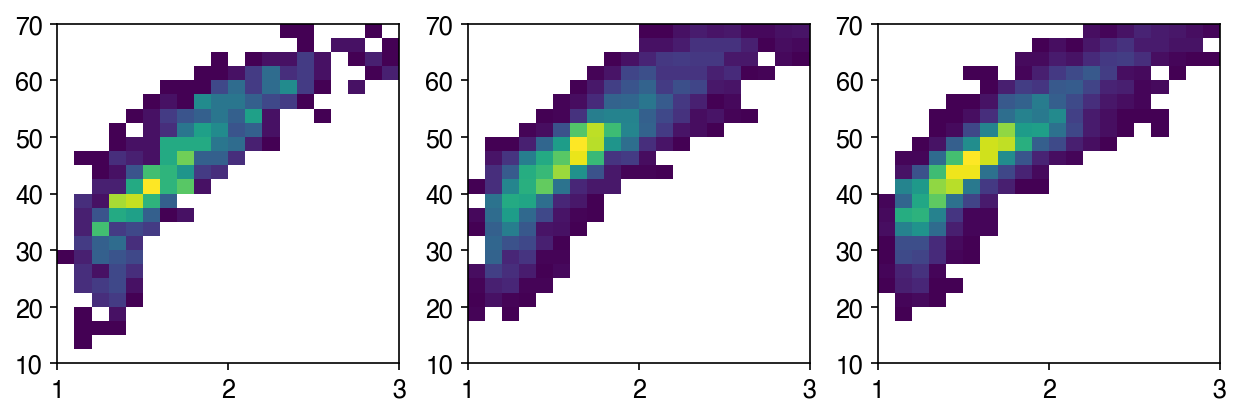

In [48]:
fig, axs = plt.subplots(1, 3, figsize=[10,3], dpi=150)

ax = axs[0]
data_arr = hist2d_cellarea_maxdbz_o.transpose()
Zm = np.ma.masked_where(data_arr <= 0, data_arr)
ax.pcolormesh(bin_cellarea, bin_maxdbz, Zm, )
# ax.colorbar()

ax = axs[1]
data_arr = hist2d_cellarea_maxdbz_d3.transpose()
Zm = np.ma.masked_where(data_arr <= 0, data_arr)
ax.pcolormesh(bin_cellarea, bin_maxdbz, Zm, )

ax = axs[2]
data_arr = hist2d_cellarea_maxdbz_d4.transpose()
Zm = np.ma.masked_where(data_arr <= 0, data_arr)
ax.pcolormesh(bin_cellarea, bin_maxdbz, Zm, )

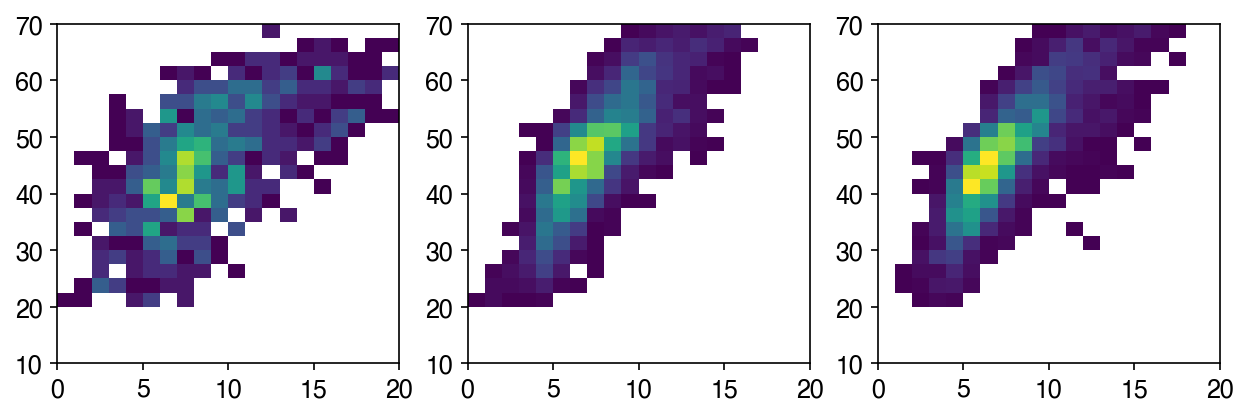

In [49]:
fig, axs = plt.subplots(1, 3, figsize=[10,3], dpi=150)

ax = axs[0]
data_arr = hist2d_eth20_maxdbz_o.transpose()
Zm = np.ma.masked_where(data_arr <= 0, data_arr)
ax.pcolormesh(bin_eth, bin_maxdbz, Zm, )
# plt.colorbar()

ax = axs[1]
data_arr = hist2d_eth20_maxdbz_d3.transpose()
Zm = np.ma.masked_where(data_arr <= 0, data_arr)
ax.pcolormesh(bin_eth, bin_maxdbz, Zm, )

ax = axs[2]
data_arr = hist2d_eth20_maxdbz_d4.transpose()
Zm = np.ma.masked_where(data_arr <= 0, data_arr)
ax.pcolormesh(bin_eth, bin_maxdbz, Zm, )

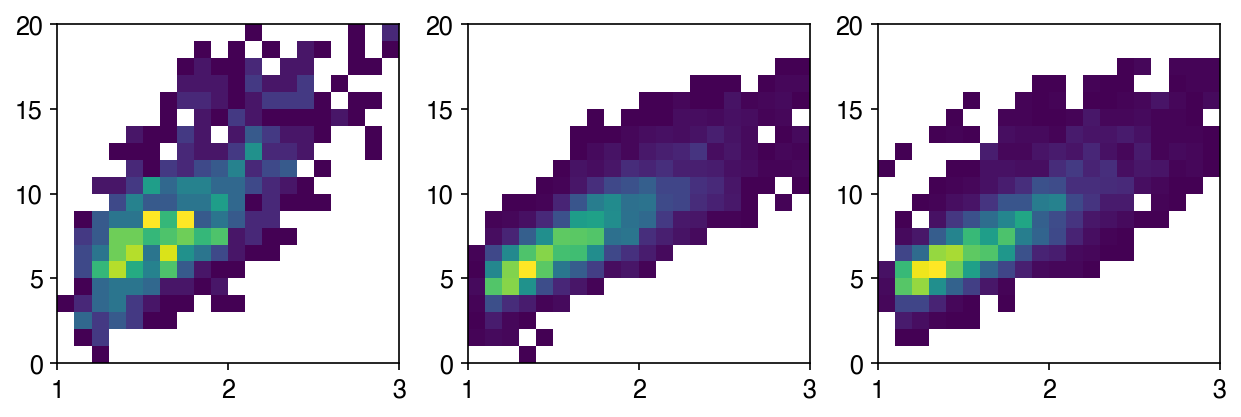

In [50]:
fig, axs = plt.subplots(1, 3, figsize=[10,3], dpi=150)

ax = axs[0]
data_arr = hist2d_cellarea_eth20_o.transpose()
Zm = np.ma.masked_where(data_arr <= 0, data_arr)
ax.pcolormesh(bin_cellarea, bin_eth, Zm, )
# plt.colorbar()

ax = axs[1]
data_arr = hist2d_cellarea_eth20_d3.transpose()
Zm = np.ma.masked_where(data_arr <= 0, data_arr)
ax.pcolormesh(bin_cellarea, bin_eth, Zm, )

ax = axs[2]
data_arr = hist2d_cellarea_eth20_d4.transpose()
Zm = np.ma.masked_where(data_arr <= 0, data_arr)
ax.pcolormesh(bin_cellarea, bin_eth, Zm, )

In [51]:
def plot_jointhist_2x3(data_arr, xbins, ybins, cmap, xlabels, ylabels, xticks, yticks, titles, cblabels, figname, levels=None):

    mpl.rcParams['font.size'] = 12
    mpl.rcParams['font.family'] = 'Helvetica'
    mpl.rcParams['figure.facecolor'] = 'white'
    fig, axes = plt.subplots(2, 3, figsize=(12, 7), dpi=100)
    cmap = plt.get_cmap(cmap)
    
    for row in range(2):
        for col in range(3):
            ax = axes[row, col]
            Zm = np.ma.masked_where(data_arr[row][col] <= 0, data_arr[row][col])
#             # Normalize colormap
#             if normal is not None:
#                 norm = mpl.colors.LogNorm(vmin=Zm.min(), vmax=Zm.max())
#             else:
#                 norm = None
            if levels is not None:
                norm = mpl.colors.BoundaryNorm(levels[row][col], ncolors=cmap.N)
            else:
                norm = None
            pcm = ax.pcolormesh(xbins[row][col], ybins[row][col], Zm, norm=norm, cmap=cmap, shading='auto')
            cb = plt.colorbar(pcm, ax=ax, label=cblabels[row][col])
            ax.grid(ls='--')
            ax.set_xlabel(xlabels[row][col])
            ax.set_ylabel(ylabels[row][col])
            ax.set_title(titles[row][col], loc='left')
            ax.set_xticks(xticks[row][col])
            ax.set_yticks(yticks[row][col])
    
    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    
    return fig

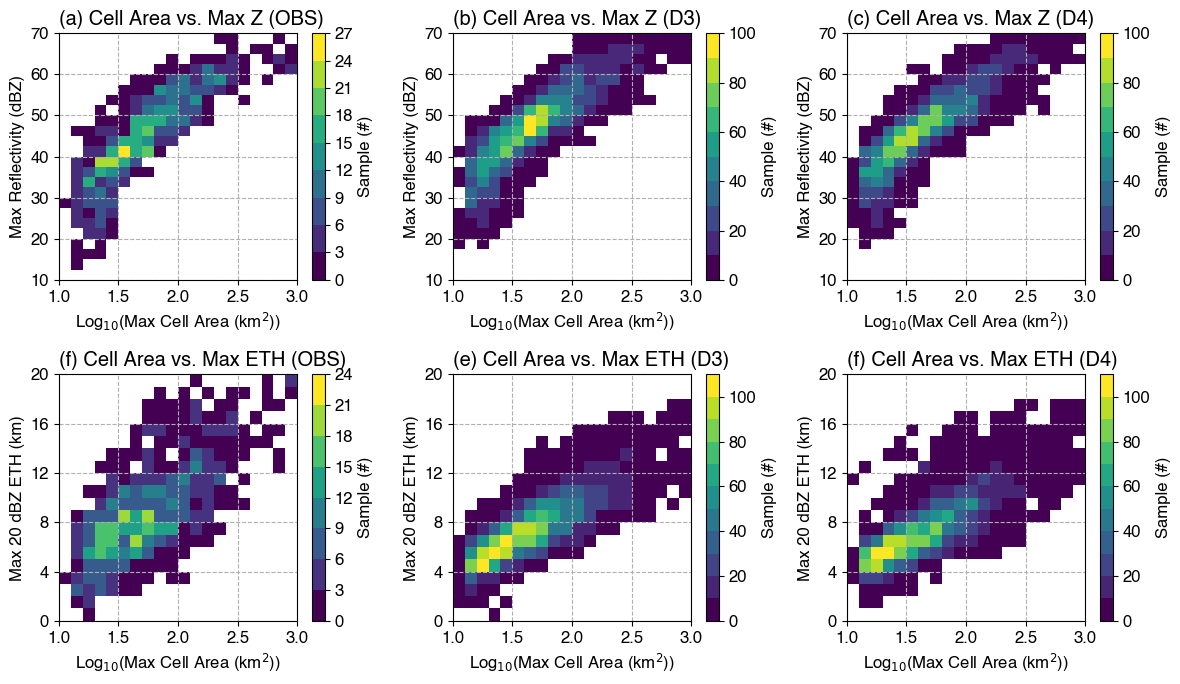

In [52]:
data_arr = [[hist2d_cellarea_maxdbz_o.transpose(), hist2d_cellarea_maxdbz_d3.transpose(), hist2d_cellarea_maxdbz_d4.transpose(),], 
            [hist2d_cellarea_eth20_o.transpose(), hist2d_cellarea_eth20_d3.transpose(), hist2d_cellarea_eth20_d4.transpose(), ]]
xbins = [[bin_cellarea, bin_cellarea, bin_cellarea],[bin_cellarea, bin_cellarea, bin_cellarea]]
ybins = [[bin_maxdbz, bin_maxdbz, bin_maxdbz], [bin_eth, bin_eth, bin_eth]]
ticks_cellarea = np.arange(1.0, 3.1, 0.5)
ticks_maxdbz = np.arange(10, 71, 10)
ticks_eth = np.arange(0, 20.1, 4)
xticks = [[ticks_cellarea, ticks_cellarea, ticks_cellarea],
          [ticks_cellarea, ticks_cellarea, ticks_cellarea]]
yticks = [[ticks_maxdbz, ticks_maxdbz, ticks_maxdbz],
          [ticks_eth, ticks_eth, ticks_eth]]
levels = [[np.arange(0,28,3), np.arange(0,101,10), np.arange(0,101,10)], 
          [np.arange(0,25,3), np.arange(0,111,10), np.arange(0,111,10)]]
cmap = 'viridis'
xlabels = [['Log$_{10}$(Max Cell Area (km$^2$))', 'Log$_{10}$(Max Cell Area (km$^2$))', 'Log$_{10}$(Max Cell Area (km$^2$))'], 
           ['Log$_{10}$(Max Cell Area (km$^2$))', 'Log$_{10}$(Max Cell Area (km$^2$))', 'Log$_{10}$(Max Cell Area (km$^2$))']]
ylabels = [['Max Reflectivity (dBZ)', 'Max Reflectivity (dBZ)', 'Max Reflectivity (dBZ)'], 
           ['Max 20 dBZ ETH (km)', 'Max 20 dBZ ETH (km)', 'Max 20 dBZ ETH (km)',]]
titles = [['(a) Cell Area vs. Max Z (OBS)', '(b) Cell Area vs. Max Z (D3)', '(c) Cell Area vs. Max Z (D4)',], 
          ['(f) Cell Area vs. Max ETH (OBS)', '(e) Cell Area vs. Max ETH (D3)', '(f) Cell Area vs. Max ETH (D4)',]]
cblabels = [['Sample (#)', 'Sample (#)',  'Sample (#)'], ['Sample (#)', 'Sample (#)',  'Sample (#)']]
figname = f'{figdir}JointHist_MaxDBZ_vs_CellStats.png'
fig = plot_jointhist_2x3(data_arr, xbins, ybins, cmap, xlabels, ylabels, xticks, yticks, titles, cblabels, figname, levels=levels)

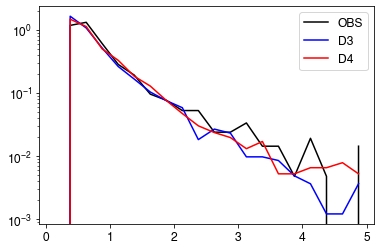

In [53]:
plt.plot(bins_lifetime_c, hist_lifetime_o, color='k', label='OBS')
plt.plot(bins_lifetime_c, hist_lifetime_d3, color='b', label='D3')
plt.plot(bins_lifetime_c, hist_lifetime_d4, color='r', label='D4')
plt.yscale('log')
plt.legend()

In [54]:
lifetime_nomerge_o = lifetime_o.isel(tracks=nonmerge_o, drop=True)
ncells_nomerge_o = lifetime_nomerge_o.count().values
ncells_nomerge_gt30min_o = np.count_nonzero(lifetime_nomerge_o > 0.5)
ncells_nomerge_ge1hour_o = np.count_nonzero(lifetime_nomerge_o >= 1.0)
frac_nomerge_gt30min_o = 100 * ncells_nomerge_gt30min_o / ncells_nomerge_o
frac_nomerge_ge1hour_o = 100 * ncells_nomerge_ge1hour_o / ncells_nomerge_o
print(f'All non-merge cells (OBS): {ncells_nomerge_o}')
print(f'Non-merge cells (OBS) > 30 min: {ncells_nomerge_gt30min_o}')
print(f'Non-merge cells (OBS) >= 1 hour: {ncells_nomerge_ge1hour_o}')
print(f'Fraction of cells (OBS) (> 30 min): {frac_nomerge_gt30min_o}%')
print(f'Fraction of cells (OBS) (>= 1 hour): {frac_nomerge_ge1hour_o}%')

All non-merge cells (OBS): 577
Non-merge cells (OBS) > 30 min: 269
Non-merge cells (OBS) >= 1 hour: 165
Fraction of cells (OBS) (> 30 min): 46.62045060658579%
Fraction of cells (OBS) (>= 1 hour): 28.596187175043326%


In [55]:
lifetime_nomerge_d3 = lifetime_d3.isel(tracks=nonmerge_d3, drop=True)
ncells_nomerge_d3 = lifetime_nomerge_d3.count().values
ncells_nomerge_gt30min_d3 = np.count_nonzero(lifetime_nomerge_d3 > 0.5)
ncells_nomerge_ge1hour_d3 = np.count_nonzero(lifetime_nomerge_d3 >= 1.0)
frac_nomerge_gt30min_d3 = 100 * ncells_nomerge_gt30min_d3 / ncells_nomerge_d3
frac_nomerge_ge1hour_d3 = 100 * ncells_nomerge_ge1hour_d3 / ncells_nomerge_d3
print(f'All non-merge cells (D3): {ncells_nomerge_d3}')
print(f'Non-merge cells (D3) > 30 min: {ncells_nomerge_gt30min_d3}')
print(f'Non-merge cells (D3) >= 1 hour: {ncells_nomerge_ge1hour_d3}')
print(f'Fraction of cells (D3) (> 30 min): {frac_nomerge_gt30min_d3}%')
print(f'Fraction of cells (D3) (>= 1 hour): {frac_nomerge_ge1hour_d3}%')

All non-merge cells (D3): 1918
Non-merge cells (D3) > 30 min: 789
Non-merge cells (D3) >= 1 hour: 475
Fraction of cells (D3) (> 30 min): 41.136600625651724%
Fraction of cells (D3) (>= 1 hour): 24.765380604796665%


In [56]:
lifetime_nomerge_d4 = lifetime_d4.isel(tracks=nonmerge_d4, drop=True)
ncells_nomerge_d4 = lifetime_nomerge_d4.count().values
ncells_nomerge_gt30min_d4 = np.count_nonzero(lifetime_nomerge_d4 > 0.5)
ncells_nomerge_ge1hour_d4 = np.count_nonzero(lifetime_nomerge_d4 >= 1.0)
frac_nomerge_gt30min_d4 = 100 * ncells_nomerge_gt30min_d4 / ncells_nomerge_d4
frac_nomerge_ge1hour_d4 = 100 * ncells_nomerge_ge1hour_d4 / ncells_nomerge_d4
print(f'All non-merge cells (D4): {ncells_nomerge_d4}')
print(f'Non-merge cells (D4) > 30 min: {ncells_nomerge_gt30min_d4}')
print(f'Non-merge cells (D4) >= 1 hour: {ncells_nomerge_ge1hour_d4}')
print(f'Fraction of cells (D4) (> 30 min): {frac_nomerge_gt30min_d4}%')
print(f'Fraction of cells (D4) (>= 1 hour): {frac_nomerge_ge1hour_d4}%')

All non-merge cells (D4): 1830
Non-merge cells (D4) > 30 min: 834
Non-merge cells (D4) >= 1 hour: 547
Fraction of cells (D4) (> 30 min): 45.57377049180328%
Fraction of cells (D4) (>= 1 hour): 29.89071038251366%


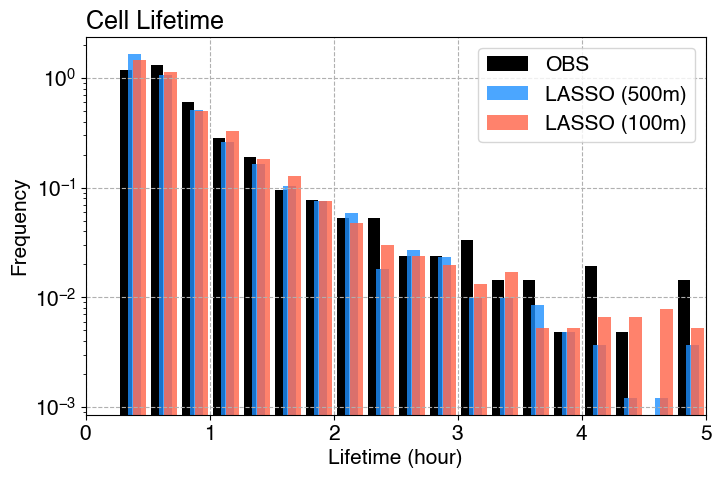

In [57]:
mpl.rcParams['font.size'] = 15
mpl.rcParams['font.family'] = 'Helvetica'
fig, ax1 = plt.subplots(1, 1, figsize=(8, 5), dpi=100)

# ax1 = fig.add_subplot(1,1,1)
ax1.set_xlabel('Lifetime (hour)')
ax1.set_ylabel('Frequency')
b1 = ax1.bar(bins_lifetime_c-0.05, hist_lifetime_o, width=0.1, color='k', label='OBS')
b2 = ax1.bar(bins_lifetime_c+0.02, hist_lifetime_d3, width=0.1, color='dodgerblue', alpha=0.8, label='LASSO (500m)')
b3 = ax1.bar(bins_lifetime_c+0.06, hist_lifetime_d4, width=0.1, color='tomato', alpha=0.8, label='LASSO (100m)')
ax1.legend()
ax1.set_xlim(0, 5)
ax1.set_title('Cell Lifetime', loc='left')
ax1.grid(ls='--')
ax1.set_yscale('log')
# fig.savefig(f'{figdir}celltrack_lifetime_pdf.png', bbox_inches='tight', dpi=300, facecolor='w')

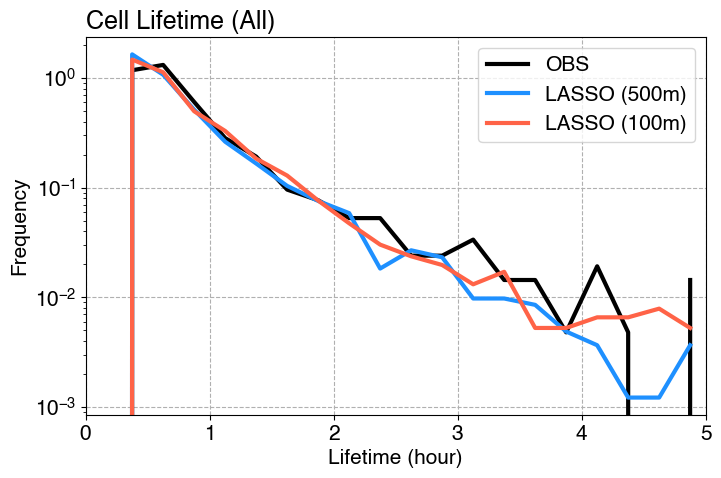

In [58]:
mpl.rcParams['font.size'] = 15
mpl.rcParams['font.family'] = 'Helvetica'
fig, ax1 = plt.subplots(1, 1, figsize=(8, 5), dpi=100)

lw = 3
ax1.set_xlabel('Lifetime (hour)')
ax1.set_ylabel('Frequency')
b1 = ax1.plot(bins_lifetime_c, hist_lifetime_o, color='k', lw=lw, label='OBS')
b2 = ax1.plot(bins_lifetime_c, hist_lifetime_d3, color='dodgerblue', lw=lw, label='LASSO (500m)')
b3 = ax1.plot(bins_lifetime_c, hist_lifetime_d4, color='tomato', lw=lw, label='LASSO (100m)')
ax1.legend()
ax1.set_xlim(0, 5)
ax1.set_title('Cell Lifetime (All)', loc='left')
ax1.grid(ls='--')
ax1.set_yscale('log')
fig.savefig(f'{figdir}celltrack_lifetime_pdf.png', bbox_inches='tight', dpi=300, facecolor='w')

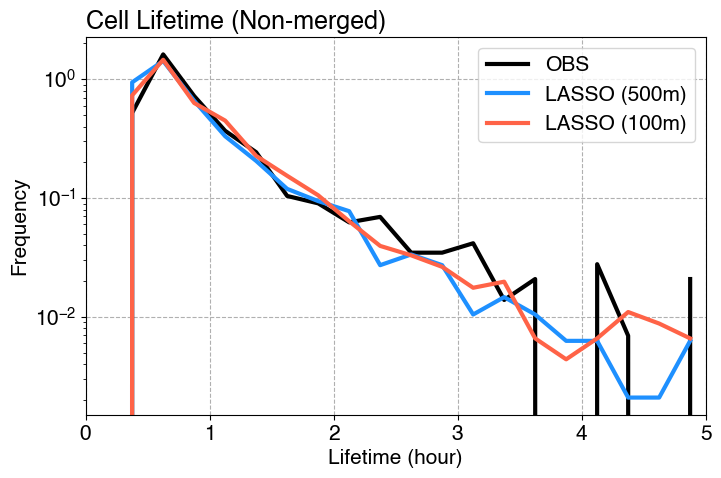

In [59]:
mpl.rcParams['font.size'] = 15
mpl.rcParams['font.family'] = 'Helvetica'
fig, ax1 = plt.subplots(1, 1, figsize=(8, 5), dpi=100)

lw = 3
ax1.set_xlabel('Lifetime (hour)')
ax1.set_ylabel('Frequency')
b1 = ax1.plot(bins_lifetime_c, hist_lifetime_nonmerge_o, color='k', lw=lw, label='OBS')
b2 = ax1.plot(bins_lifetime_c, hist_lifetime_nonmerge_d3, color='dodgerblue', lw=lw, label='LASSO (500m)')
b3 = ax1.plot(bins_lifetime_c, hist_lifetime_nonmerge_d4, color='tomato', lw=lw, label='LASSO (100m)')
ax1.legend()
ax1.set_xlim(0, 5)
ax1.set_title('Cell Lifetime (Non-merged)', loc='left')
ax1.grid(ls='--')
ax1.set_yscale('log')
fig.savefig(f'{figdir}celltrack_lifetime_nonmerge_pdf.png', bbox_inches='tight', dpi=300, facecolor='w')

In [61]:
# from scipy.stats import norm


In [63]:
hist_lifetime_nonmerge_o

array([0.        , 0.52083333, 1.61805556, 0.72222222, 0.36805556,
       0.24305556, 0.10416667, 0.09027778, 0.0625    , 0.06944444,
       0.03472222, 0.03472222, 0.04166667, 0.01388889, 0.02083333,
       0.        , 0.02777778, 0.00694444, 0.        , 0.02083333])

# Plot KDE of cell lifetime

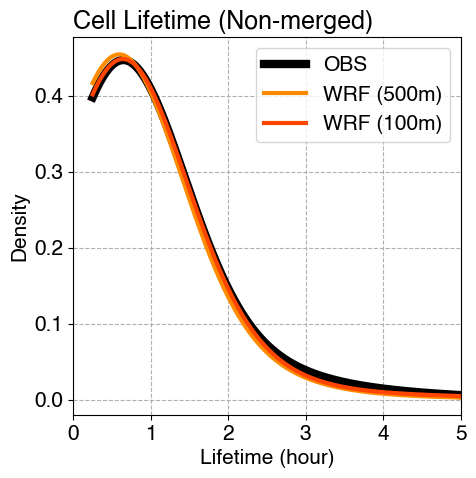

In [118]:
# Select non-merge cells
X_o = lifetime_o.data[:, np.newaxis]
X_d3 = lifetime_d3.data[:, np.newaxis]
X_d4 = lifetime_d4.data[:, np.newaxis]
X_nonmerge_o = lifetime_o.isel(tracks=nonmerge_o).data[:, np.newaxis]
X_nonmerge_d3 = lifetime_d3.isel(tracks=nonmerge_d3).data[:, np.newaxis]
X_nonmerge_d4 = lifetime_d4.isel(tracks=nonmerge_d4).data[:, np.newaxis]

# Estimate 1D KDE following sklearn example
# https://scikit-learn.org/stable/auto_examples/neighbors/plot_kde_1d.html
kde_bw = 0.75
# kde_kernel = 'epanechnikov'
# kde_kernel = 'exponential'
kde_kernel = 'gaussian'
kde_nonmerge_o = KernelDensity(kernel=kde_kernel, bandwidth=kde_bw).fit(X_nonmerge_o)
kde_nonmerge_d3 = KernelDensity(kernel=kde_kernel, bandwidth=kde_bw).fit(X_nonmerge_d3)
kde_nonmerge_d4 = KernelDensity(kernel=kde_kernel, bandwidth=kde_bw).fit(X_nonmerge_d4)
kde_o = KernelDensity(kernel=kde_kernel, bandwidth=kde_bw).fit(X_o)
kde_d3 = KernelDensity(kernel=kde_kernel, bandwidth=kde_bw).fit(X_d3)
kde_d4 = KernelDensity(kernel=kde_kernel, bandwidth=kde_bw).fit(X_d4)

X_plot = np.linspace(0.25, 5, 1000)[:, np.newaxis]
log_dens_nonmerge_o = kde_nonmerge_o.score_samples(X_plot)
log_dens_nonmerge_d3 = kde_nonmerge_d3.score_samples(X_plot)
log_dens_nonmerge_d4 = kde_nonmerge_d4.score_samples(X_plot)
log_dens_o = kde_o.score_samples(X_plot)
log_dens_d3 = kde_d3.score_samples(X_plot)
log_dens_d4 = kde_d4.score_samples(X_plot)

mpl.rcParams['font.size'] = 15
mpl.rcParams['font.family'] = 'Helvetica'
fig, ax1 = plt.subplots(1, 1, figsize=(5, 5), dpi=100)

lw = 3
lcolors = {'o':'k', 'd3':'darkorange', 'd4':'orangered'}
ax1.set_xlabel('Lifetime (hour)')
ax1.set_ylabel('Density')
# ax1.plot(X_plot[:,0], np.exp(log_dens_o), color='k', lw=lw, ls='--', label='OBS')
# ax1.plot(X_plot[:,0], np.exp(log_dens_d3), color='dodgerblue', lw=lw, ls='--', label='WRF (500m)')
# ax1.plot(X_plot[:,0], np.exp(log_dens_d4), color='tomato', lw=lw, ls='--', label='WRF (100m)')
ax1.plot(X_plot[:,0], np.exp(log_dens_nonmerge_o), color=lcolors['o'], lw=lw*2, label='OBS')
ax1.plot(X_plot[:,0], np.exp(log_dens_nonmerge_d3), color=lcolors['d3'], lw=lw, label='WRF (500m)')
ax1.plot(X_plot[:,0], np.exp(log_dens_nonmerge_d4), color=lcolors['d4'], lw=lw, label='WRF (100m)')
# ax1.plot(X_plot[:,0], (log_dens_o), color='k', lw=lw, label='OBS')
# ax1.plot(X_plot[:,0], (log_dens_d3), color='dodgerblue', lw=lw, label='WRF (500m)')
# ax1.plot(X_plot[:,0], (log_dens_d4), color='tomato', lw=lw, label='WRF (100m)')

# b1 = ax1.plot(bins_lifetime_c, hist_lifetime_nonmerge_o, color='k', lw=lw, label='OBS')

ax1.legend()
ax1.set_xlim(0, 5)
ax1.set_title('Cell Lifetime (Non-merged)', loc='left')
ax1.grid(ls='--')
fig.savefig(f'{figdir}celltrack_lifetime_nonmerge_kde.png', bbox_inches='tight', dpi=300, facecolor='w')

In [117]:
figdir

'/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les/figures/'

In [106]:
def plot_jointdist(x_obs, y_obs, x_m1, y_m1, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname,
                   lcolors=None, legend_labels=None, legend_loc='lower right'):
    mpl.rcParams['font.family'] = 'Helvetica'
    g = sns.JointGrid(height=8, ratio=5, space=.3, marginal_ticks=False, xlim=xlim, ylim=ylim)

    # lcolors = {'obs':'steelblue', 'model':'darkorange'}
    cmap = copy.copy(mpl.cm.get_cmap('Blues'))
    cmap = truncate_colormap(cmap, 0.1, 1)
    sns.kdeplot(x=x_obs, y=y_obs, levels=levels, fill=True, cmap=cmap, alpha=0.9, ax=g.ax_joint)
    sns.kdeplot(x=x_m1, y=y_m1, color=lcolors['model'], levels=levels, fill=False, ax=g.ax_joint)
    sns.kdeplot(x=x_obs, color=lcolors['obs'], ax=g.ax_marg_x)
    sns.kdeplot(x=x_m1, color=lcolors['model'], ax=g.ax_marg_x)
    sns.kdeplot(y=y_obs, color=lcolors['obs'], ax=g.ax_marg_y)
    sns.kdeplot(y=y_m1, color=lcolors['model'], ax=g.ax_marg_y)
    legend_elements = [mpl.patches.Patch(facecolor=lcolors['obs'], edgecolor='b'),
                       mpl.lines.Line2D([0], [0], color=lcolors['model'])]
    # legend_labels = ['OBS', 'SCREAM']
    leg = mpl.legend.Legend(g.ax_joint, handles=legend_elements, labels=legend_labels, 
                            loc=legend_loc, facecolor='w', prop={'family':'Helvetica', 'size':18})
    g.ax_joint.text(0.95, 0.95, annotate_text, ha='right', va='center', transform=g.ax_joint.transAxes)
    g.ax_joint.add_artist(leg)
    g.set_axis_labels(xlabel=xlabel, ylabel=ylabel)
    g.ax_marg_x.set_ylabel('')
    g.ax_marg_y.set_xlabel('')

    g.savefig(figname, dpi=300, facecolor='w')
    # sns.JointGrid(marginal_ticks=True)
    return g

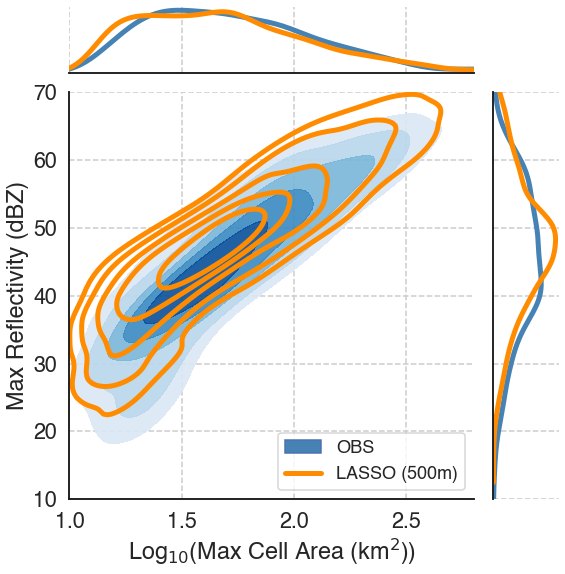

In [61]:
# Set Seaborn plot style
sns.set_theme('talk', style='whitegrid', font_scale=1.3, 
              rc={'lines.linewidth':5, 'font.family':'Helvetica', 'axes.edgecolor':'k', 'grid.linestyle':'--'})


x_obs, y_obs = np.log10(cell_area_o).max(dim='times').data, maxdbz_o.max(dim='times').data
x_m, y_m = np.log10(cell_area_d3).max(dim='times').data, maxdbz_d3.max(dim='times').data
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlim = (1,2.8)
ylim = (10,70)
xlabel = 'Log$_{10}$(Max Cell Area (km$^2$))'
ylabel = 'Max Reflectivity (dBZ)'
annotate_text = ''
lcolors = {'obs':'steelblue', 'model':'darkorange'}
legend_labels = ['OBS', 'LASSO (500m)']
figname = f'{figdir}KDE_MaxArea_MaxDBZ_d3.png'
g = plot_jointdist(x_obs, y_obs, x_m, y_m, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, 
                   lcolors=lcolors, legend_labels=legend_labels, )

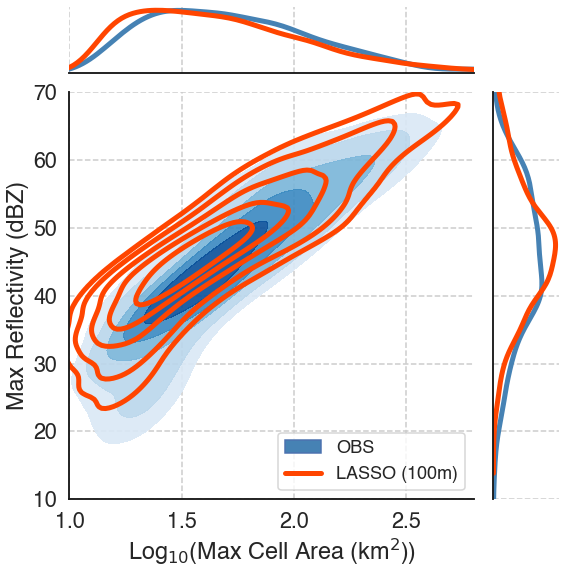

In [62]:
x_obs, y_obs = np.log10(cell_area_o).max(dim='times').data, maxdbz_o.max(dim='times').data
x_m, y_m = np.log10(cell_area_d4).max(dim='times').data, maxdbz_d4.max(dim='times').data
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlim = (1,2.8)
ylim = (10,70)
xlabel = 'Log$_{10}$(Max Cell Area (km$^2$))'
ylabel = 'Max Reflectivity (dBZ)'
annotate_text = ''
lcolors = {'obs':'steelblue', 'model':'orangered'}
legend_labels = ['OBS', 'LASSO (100m)']
figname = f'{figdir}KDE_MaxArea_MaxDBZ_d4.png'
g = plot_jointdist(x_obs, y_obs, x_m, y_m, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, 
                   lcolors=lcolors, legend_labels=legend_labels, )

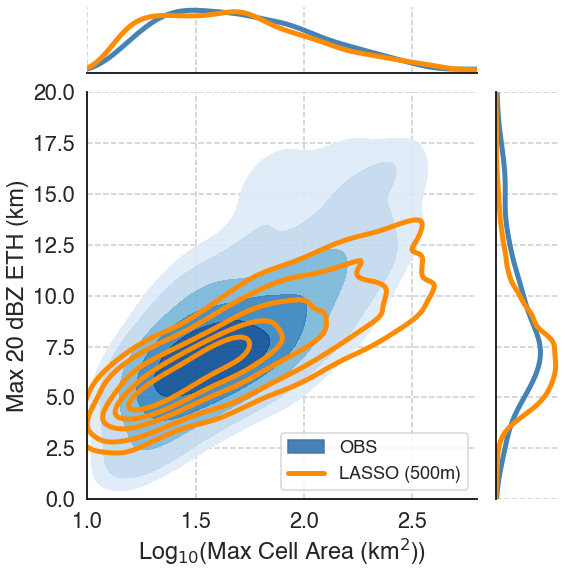

In [63]:
x_obs, y_obs = np.log10(cell_area_o).max(dim='times').data, eth20_o.max(dim='times').data
x_m, y_m = np.log10(cell_area_d3).max(dim='times').data, eth20_d3.max(dim='times').data
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlim = (1,2.8)
ylim = (0,20)
xlabel = 'Log$_{10}$(Max Cell Area (km$^2$))'
ylabel = 'Max 20 dBZ ETH (km)'
annotate_text = ''
lcolors = {'obs':'steelblue', 'model':'darkorange'}
legend_labels = ['OBS', 'LASSO (500m)']
figname = f'{figdir}KDE_MaxArea_MaxETH20dBZ_d3.png'
g = plot_jointdist(x_obs, y_obs, x_m, y_m, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, 
                   lcolors=lcolors, legend_labels=legend_labels, )

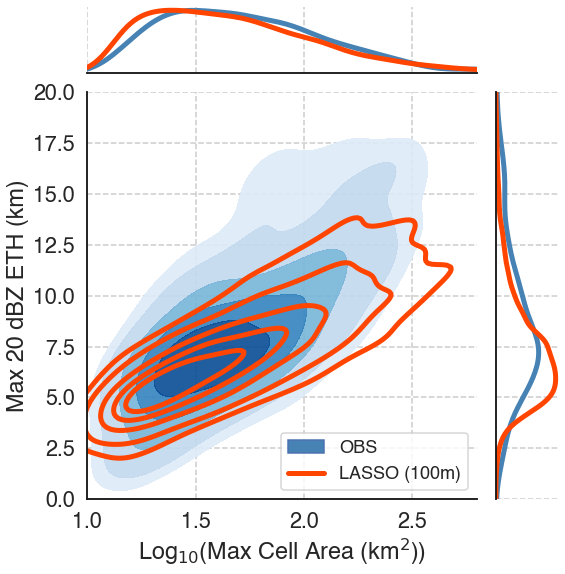

In [64]:
x_obs, y_obs = np.log10(cell_area_o).max(dim='times').data, eth20_o.max(dim='times').data
x_m, y_m = np.log10(cell_area_d4).max(dim='times').data, eth20_d4.max(dim='times').data
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlim = (1,2.8)
ylim = (0,20)
xlabel = 'Log$_{10}$(Max Cell Area (km$^2$))'
ylabel = 'Max 20 dBZ ETH (km)'
annotate_text = ''
lcolors = {'obs':'steelblue', 'model':'orangered'}
legend_labels = ['OBS', 'LASSO (100m)']
figname = f'{figdir}KDE_MaxArea_MaxETH20dBZ_d4.png'
g = plot_jointdist(x_obs, y_obs, x_m, y_m, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, 
                   lcolors=lcolors, legend_labels=legend_labels, )

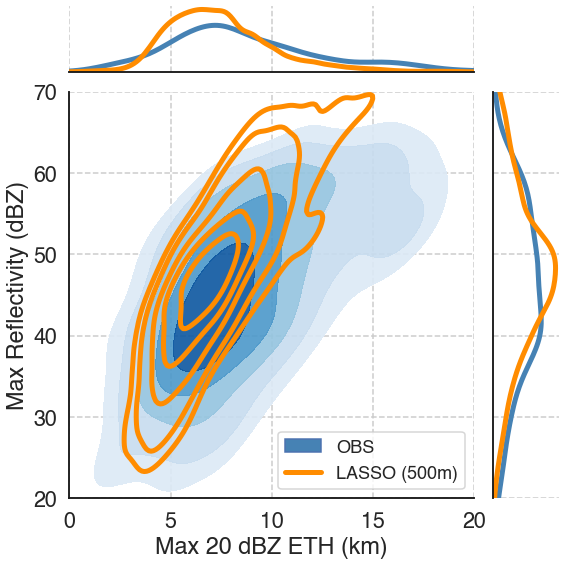

In [65]:
x_obs, y_obs = eth20_o.max(dim='times').data, maxdbz_o.max(dim='times').data
x_m, y_m = eth20_d3.max(dim='times').data, maxdbz_d3.max(dim='times').data
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlim = (0,20)
ylim = (20,70)
xlabel = 'Max 20 dBZ ETH (km)'
ylabel = 'Max Reflectivity (dBZ)'
annotate_text = ''
lcolors = {'obs':'steelblue', 'model':'darkorange'}
legend_labels = ['OBS', 'LASSO (500m)']
figname = f'{figdir}KDE_MaxETH20dBZ_MaxDBZ_d3.png'
g = plot_jointdist(x_obs, y_obs, x_m, y_m, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, 
                   lcolors=lcolors, legend_labels=legend_labels, )

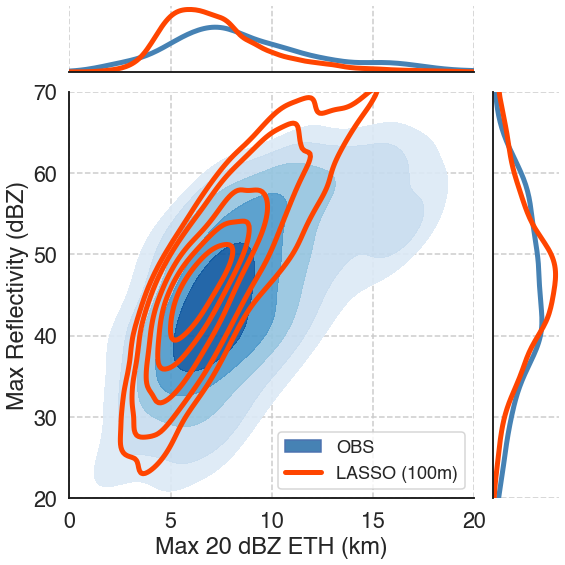

In [66]:
x_obs, y_obs = eth20_o.max(dim='times').data, maxdbz_o.max(dim='times').data
x_m, y_m = eth20_d4.max(dim='times').data, maxdbz_d4.max(dim='times').data
levels = [0.1,0.2,0.4,0.6,0.8,1]
xlim = (0,20)
ylim = (20,70)
xlabel = 'Max 20 dBZ ETH (km)'
ylabel = 'Max Reflectivity (dBZ)'
annotate_text = ''
lcolors = {'obs':'steelblue', 'model':'orangered'}
legend_labels = ['OBS', 'LASSO (100m)']
figname = f'{figdir}KDE_MaxETH20dBZ_MaxDBZ_d4.png'
g = plot_jointdist(x_obs, y_obs, x_m, y_m, levels, xlim, ylim, xlabel, ylabel, annotate_text, figname, 
                   lcolors=lcolors, legend_labels=legend_labels, )